# **Étude de marché internationale : La poule qui chante**

### **Partie 1 : Préparation, nettoyage et analyse exploratoire des données**

<center>
    <img src="img/poule_chante_logo.png" width="200">
</center>

⚠️ **Avertissement** : 

Ce document est le premier des deux notebooks qui composent notre étude de marché internationale. Il est consacré à la préparation, au nettoyage et à l'analyse exploratoire des données (EDA). 

Les algorithmes de Machine Learning (ACP et Clustering CAH & K-Means) permettant de cibler les pays finaux sont développés dans le second notebook.

----

**Contexte de la mission** : 

Nous travaillons au sein de "La Poule Qui Chante", une entreprise d’agroalimentaire française dont l’activité principale est l’élevage et la vente de volailles haut de gamme sous le label Agriculture Biologique (AB).

Notre succès sur le territoire national n'est plus à démontrer, notre ambition est désormais de nous développer à l'international. À ce stade du projet, le champ des possibles est totalement ouvert : aucun continent ni pays cible n'a été présélectionné, le monde entier est envisageable !

**Notre mission** : utiliser la donnée et les indicateurs macro-économiques mondiaux pour déceler, en toute objectivité, les marchés étrangers présentant le meilleur potentiel d'accueil pour nos produits premium.

---

**Sources des données et dictionnaire des variables retenues** : 

Pour garantir la fiabilité de notre analyse, nous nous appuyons sur des bases de données institutionnelles ouvertes (Open Data) :

- **FAO** (Food and Agriculture Organization) & **Banque Mondiale** : Pour les bilans alimentaires, les dynamiques d'import/export de volaille, la démographie, ainsi que les indicateurs macro-économiques (PIB) et de gouvernance (stabilité politique).

- **Université de Yale** (Score EPI) : Pour l'indice de performance environnementale, pour cibler un marché réceptif au "Bio".


Après une analyse PESTEL (Politique, Économique, Sociologique, Technologique, Environnemental, Légal) de notre offre et de nos besoins logistiques, nous avons isolé 9 indicateurs clés qui composeront notre matrice d'analyse :

| Nom de la variable   | Intitulé fonctionnel                 |      Description & enjeu métier                                                                                              |
| ----------------------------------- | -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| `population_totale_2017`                 | Population du pays                     | Taille du marché pour évaluer le volume de consommateurs potentiels.                                                 |
| `croissance_demo_2012_2017_pct`                   | Évolution démographique de 2012 à 2017 (en %)                   | Dynamique du marché pour indiquer si la clientèle potentielle est en forte expansion.                                                |
| `pib_habitant_usd`                  | PIB par habitant (en US$)              | Pouvoir d'achat pour évaluer la capacité à acheter un produit Bio (plus cher).                                 |
| `conso_volaille_kg_hab`                | Consommation de volaille par habitant | Consommation de volaille pour confirmer que le pays consomme traditionnellement du poulet.                                         |
| `importations_volaille_kg`             | Importations de volaille (Kilo)      | Ouverture commerciale pour voir si il y a une dépendance et un marché déjà ouvert à l'international.    |
| `tdi_volaille_pct`               | Taux de dépendance aux Importations (en %) | Pays dépendants aux importations de volaille ou non [TDI =(Importations) / (Production + Importations)*100].                                    |
| `conso_volaille_pct`               | Par de la consommation de volaille (en %)          | Part de consommation de volaille par rapport aux autres viandes (boeuf, porc).                   |
| `indice_stabilite_politique`               | Indice de stabilité politique          | Risque politique pour sécuriser les contrats d'exportation et la chaîne logistique.                   |
| `indice_score_epi`                         | Indice de Performance Environnementale | Sensibilité écologique pour identifier les pays sensibles aux produits certifiés Agriculture Biologique. |

---

<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 1 - Préparation et fusion des données</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.1 - Import des librairies et chargement des fichiers</h3>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 10px; color: RGB(127,148,128); ">1.1.1 - Import des librairies </h4>
</div>

In [1]:
# Import des librairies
import pandas as pd
import numpy as np

import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Augmentation du nombre de colonnes affichées dans les DataFrame
pd.set_option("display.max_columns", 30)

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 10px; color: RGB(127,148,128); ">1.1.2 - Import des fichiers</h4>
</div>

In [3]:
# Import des fichiers
df_dispo_alim = pd.read_csv("../data/raw/DisponibiliteAlimentaire_2017.csv")
df_pop = pd.read_csv("../data/raw/Population_2000_2018.csv")
df_pib = pd.read_csv("../data/raw/PIB_hab_2017.csv")
df_securite = pd.read_csv("../data/raw/Securite_2017.csv")
df_epi_score = pd.read_csv("../data/raw/EPI_Score_2018.csv", sep=";")

In [4]:
# Affichage des dataframes
print("---------- Disponibiltié Alimentaire ----------")
display(df_dispo_alim.head(3))
print("---------- Population ----------")
display(df_pop.head(3))
print("---------- PIB Habitants USD ----------")
display(df_pib.head(3))
print("---------- Sécurité ----------")
display(df_securite.head(3))
print("---------- EPI Score ----------")
display(df_epi_score.head(3))

---------- Disponibiltié Alimentaire ----------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées


---------- Population ----------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN


---------- PIB Habitants USD ----------


,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,MK,Indicateurs macro,4,Afghanistan,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,533.339061,X,Chiffre de source externe,NaN
1,MK,Indicateurs macro,710,Afrique du Sud,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,6612.920015,X,Chiffre de source externe,NaN
2,MK,Indicateurs macro,8,Albanie,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,4492.285003,X,Chiffre de source externe,NaN


---------- Sécurité ----------


,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,4,Afghanistan,6121,Valeur,21033,Valeur des importations alimentaires par rappo...,20162018,2016-2018,%,378.00,E,Valeur estimée,NaN
1,FS,Données de la sécurité alimentaire,4,Afghanistan,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,-2.79,X,Chiffre de source externe,NaN
2,FS,Données de la sécurité alimentaire,710,Afrique du Sud,6121,Valeur,21033,Valeur des importations alimentaires par rappo...,20162018,2016-2018,%,6.00,E,Valeur estimée,NaN


---------- EPI Score ----------


,code,iso,country,EPI.current,HLT.current,AIR.current,H2O.current,HMT.current,ECO.current,BDH.current,FOR.current,FSH.current,CCE.current,APE.current,WRS.current,...,SPI.current,PAR.current,SHI.current,TCL.current,FSS.current,MTR.current,DCT.current,DPT.current,DMT.current,DNT.current,DBT.current,DST.current,DXT.current,WWT.current,SNM.current
0,4,AFG,Afghanistan,"37,74","36,76","44,67","25,75",0,"38,4","13,44","99,07",-9999,"33,04","91,44",0,...,"3,07",7,"90,6","99,07",-9999,-9999,"23,47",-9999,"53,62","50,1","67,66","82,88",100,0,"44,77"
1,8,ALB,Albania,"65,46","65,67","65,47","66,56","62,89","65,32","75,37","23,36","58,25","68,36","86,07","80,73",...,"32,09","56,94","81,81","23,36","54,73","61,77","53,77",100,"73,3","63,65","72,61","83,25","88,9","80,73","22,61"
2,12,DZA,Algeria,"57,18","80,95","93,98","60,26","35,6","41,34","49,33","9,96","44,39","26,94","46,15","91,6",...,"53,93","10,06","80,45","9,96","28,21","60,58","17,14","46,35","37,76","23,99","6,93","83,63","8,68","91,6","34,26"


<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2 - Nettoyage et audit des données</h3>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.1 - Fichier Disponibiltié Alimentaire</h4>
</div>

In [5]:
# Afficher les dimensions du dataset
nb_lignes = df_dispo_alim.shape[0]
nb_colonnes = df_dispo_alim.shape[1]
print(f"Le tableau comporte {nb_lignes} observations et {nb_colonnes} colonnes")

Le tableau comporte 176600 observations et 14 colonnes


In [6]:
# Selection des colonnes pertinentes
df_dispo_alim = df_dispo_alim[["Code zone", "Zone", "Élément", "Produit", "Valeur"]]
df_dispo_alim.head()

,Code zone,Zone,Élément,Produit,Valeur
0,2,Afghanistan,Production,Blé et produits,4281.0
1,2,Afghanistan,Importations - Quantité,Blé et produits,2302.0
2,2,Afghanistan,Variation de stock,Blé et produits,-119.0
3,2,Afghanistan,Exportations - Quantité,Blé et produits,0.0
4,2,Afghanistan,Disponibilité intérieure,Blé et produits,6701.0


<div style="border: 1px solid RGB(127,148,128);" >
<h5 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.1.1 - Calcul de la part de volaille dans la viande</h5>
</div>

In [7]:
# Affichage des différents "Éléments"
df_dispo_alim["Élément"].unique()

<StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                            'Variation de stock',
                                       'Exportations - Quantité',
                                      'Disponibilité intérieure',
                                         'Aliments pour animaux',
                                                      'Semences',
                                                        'Pertes',
                                                       'Résidus',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
                                                    'Traitemen

In [8]:
# Affichage de toutes les viandes
produits_viande = df_dispo_alim[
    df_dispo_alim["Produit"].str.contains("Viande", na=False)
]["Produit"].unique()
print(produits_viande)

<StringArray>
[      'Viande de Bovins', 'Viande d'Ovins/Caprins',       'Viande de Suides',
    'Viande de Volailles',          'Viande, Autre', 'Viande de Anim Aquatiq']
Length: 6, dtype: str


In [9]:
# Création d'une liste avec toutes les viandes
liste_viandes = [
    "Viande de Bovins",
    "Viande d'Ovins/Caprins",
    "Viande de Suides",
    "Viande de Volailles",
    "Viande, Autre",
    "Viande de Anim Aquatiq",
]

In [10]:
# Création des masques "Produit" "Viandes" et seulement la disponibilité en kg
mask_viandes = df_dispo_alim["Produit"].isin(liste_viandes)
mask_element = (
    df_dispo_alim["Élément"] == "Disponibilité alimentaire en quantité (kg/personne/an)"
)

In [11]:
# Création d'un dataframe "Viandes"
df_viandes = df_dispo_alim[mask_viandes & mask_element]

In [12]:
# Pivot Table pour préparer les calculs de chaque viande
pivot_viandes = df_viandes.pivot_table(
    index=["Code zone", "Zone"], columns="Produit", values="Valeur", aggfunc="sum"
).reset_index()
pivot_viandes.columns.name = None

In [13]:
# Calcul du total et du pourcentage
pivot_viandes["conso_viande_total_kg_hab"] = (
    pivot_viandes[liste_viandes].fillna(0).sum(axis=1)
)
pivot_viandes["conso_volaille_pct"] = (
    pivot_viandes["Viande de Volailles"] / pivot_viandes["conso_viande_total_kg_hab"]
) * 100

In [14]:
# Sélection et renommage des colonnes
df_part_viandes = pivot_viandes[
    [
        "Code zone",
        "Zone",
        "Viande de Volailles",
        "conso_viande_total_kg_hab",
        "conso_volaille_pct",
    ]
].copy()
df_part_viandes = df_part_viandes.rename(
    columns={"Viande de Volailles": "conso_volaille_kg_hab"}
)

<div style="border: 1px solid RGB(127,148,128);" >
<h5 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.1.1 - Calcul du Taux de dépendance aux importations (TDI) pour les volailles </h5>
</div>

In [15]:
# Création des masques "Produit" "Viande de volailles" et uniquement Import et Production
mask_volaille = df_dispo_alim["Produit"] == "Viande de Volailles"
mask_elements_tdi = df_dispo_alim["Élément"].isin(
    ["Importations - Quantité", "Production"]
)

In [16]:
# Création d'un dataframe "Volaille" avec Import et Production
df_prod_import = df_dispo_alim[mask_volaille & mask_elements_tdi]

In [17]:
# Pivot Table pour préparer le calculs de TDI de la volaille
pivot_tdi = df_prod_import.pivot_table(
    index=["Code zone", "Zone"], columns="Élément", values="Valeur", aggfunc="sum"
).reset_index()
pivot_tdi.columns.name = None
pivot_tdi = pivot_tdi.fillna(0)

In [18]:
print(pivot_tdi.columns.tolist())

['Code zone', 'Zone', 'Importations - Quantité', 'Production']


In [19]:
# Calcul du TDI en pourcentage
pivot_tdi["tdi_volaille_pct"] = (
    pivot_tdi["Importations - Quantité"]
    / (pivot_tdi["Production"] + pivot_tdi["Importations - Quantité"])
) * 100

In [20]:
# On convertit les volumes bruts en Kg
pivot_tdi["importations_volaille_kg"] = pivot_tdi["Importations - Quantité"] * 1000000
pivot_tdi["production_volaille_kg"] = pivot_tdi["Production"] * 1000000

In [21]:
# Nettoyage du dataframe TDI
df_part_tdi = pivot_tdi[
    [
        "Code zone",
        "Zone",
        "importations_volaille_kg",
        "production_volaille_kg",
        "tdi_volaille_pct",
    ]
].copy()

<div style="border: 1px solid RGB(127,148,128);" >
<h5 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.1.3 - Fusion des deux dataframes (Part Volaille et TDI %) et nettoyage final </h5>
</div>

In [22]:
# Rassemblement des deux dataframes
df_volaille_final = pd.merge(
    df_part_viandes, df_part_tdi, on=["Code zone", "Zone"], how="left"
)

In [23]:
# Arrondit des pourcentages et gestion des divisions par zero
df_volaille_final["conso_volaille_pct"] = (
    df_volaille_final["conso_volaille_pct"].fillna(0).round(2)
)
df_volaille_final["tdi_volaille_pct"] = (
    df_volaille_final["tdi_volaille_pct"].fillna(0).round(2)
)
df_volaille_final = df_volaille_final.rename(
    columns={"Code zone": "code_fao", "Zone": "pays"}
)

In [24]:
# Audit des dimensions, doublons et valeurs manquantes du dataframe
audit_dataframes = {"Volaille": df_volaille_final}
for nom, df in audit_dataframes.items():
    print(f"---------- Audit du fichier {nom} ----------")
    print(f"Dimensions : {df.shape[0]} lignes & {df.shape[1]} colonnes")
    print(f"Doublons totaux : {df.duplicated().sum()}")

    # Affichage des valeurs manquantes (NaN) par colonne
    print("-" * 20)
    print("Valeurs manquantes par colonne :")
    print(df.isna().sum())

    print("-" * 20)
    df.info()

    # Affichage global
    print("-" * 20)
    display(df.head(3))
    print("\n\n")

---------- Audit du fichier Volaille ----------
Dimensions : 172 lignes & 8 colonnes
Doublons totaux : 0
--------------------
Valeurs manquantes par colonne :
code_fao                     0
pays                         0
conso_volaille_kg_hab        0
conso_viande_total_kg_hab    0
conso_volaille_pct           0
importations_volaille_kg     2
production_volaille_kg       2
tdi_volaille_pct             0
dtype: int64
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   code_fao                   172 non-null    int64  
 1   pays                       172 non-null    str    
 2   conso_volaille_kg_hab      172 non-null    float64
 3   conso_viande_total_kg_hab  172 non-null    float64
 4   conso_volaille_pct         172 non-null    float64
 5   importations_volaille_kg   170 non-null    float64
 6   production_vo

,code_fao,pays,conso_volaille_kg_hab,conso_viande_total_kg_hab,conso_volaille_pct,importations_volaille_kg,production_volaille_kg,tdi_volaille_pct
0,1,Arménie,16.06,45.65,35.18,35000000.0,11000000.0,76.09
1,2,Afghanistan,1.53,8.59,17.81,29000000.0,28000000.0,50.88
2,3,Albanie,16.36,47.51,34.43,38000000.0,13000000.0,74.51


In [25]:
# Filtre du tableau pour ne garder que les lignes ayant au moins un NaN
pays_avec_nan = df_volaille_final[df_volaille_final.isna().any(axis=1)]
display(pays_avec_nan)

,code_fao,pays,conso_volaille_kg_hab,conso_viande_total_kg_hab,conso_volaille_pct,importations_volaille_kg,production_volaille_kg,tdi_volaille_pct
84,120,République démocratique populaire lao,10.91,30.40,35.89,NaN,NaN,0.0
160,235,Ouzbékistan,1.96,34.41,5.70,NaN,NaN,0.0


L'Ouzbékistan, le Laos sont des pays avec des valeurs manquantes sur les volumes d'import/production de viande de volailles. 

L'opacité de ces marchés représente un risque stratégique trop élevé pour une première phase d'expansion internationale. 

Je prends donc la décision d'exclure ces deux pays de notre étude de marché globale.

In [26]:
df_volaille_final = df_volaille_final.dropna()
print(f"Pays restants : {df_volaille_final.shape[0]}")

Pays restants : 170


Il reste donc 170 pays avec des données structurantes sur la disponibilité de volaille par habitant, les importations et la production de volaille.

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.2 - Fichier Population</h4>
</div>

In [27]:
# Afficher les dimensions du dataset
nb_lignes = df_pop.shape[0]
nb_colonnes = df_pop.shape[1]
print(f"Le tableau comporte {nb_lignes} observations et {nb_colonnes} colonnes")

Le tableau comporte 4411 observations et 15 colonnes


In [28]:
# Selection des colonnes pertinentes
df_pop = df_pop[["Code zone", "Zone", "Année", "Valeur"]]
df_pop.head()

,Code zone,Zone,Année,Valeur
0,2,Afghanistan,2000,20779.953
1,2,Afghanistan,2001,21606.988
2,2,Afghanistan,2002,22600.770
3,2,Afghanistan,2003,23680.871
4,2,Afghanistan,2004,24726.684


Pour calculer l'évolution de la démographie nous remontons de 5 années pour avoir évolution relativement récente c'est à dire de 2012 à 2017.

In [29]:
# Création du masque "Année" pour sélectionner les année 2012 et 2017
mask_annees = df_pop["Année"].isin([2012, 2017])
df_pop_croissance = df_pop[mask_annees]
display(df_pop_croissance.head(10))

,Code zone,Zone,Année,Valeur
12,2,Afghanistan,2012,31161.376
17,2,Afghanistan,2017,36296.113
31,202,Afrique du Sud,2012,52832.658
36,202,Afrique du Sud,2017,57009.756
50,3,Albanie,2012,2914.096
55,3,Albanie,2017,2884.169
69,4,Algérie,2012,37383.895
74,4,Algérie,2017,41389.189
88,79,Allemagne,2012,80972.628
93,79,Allemagne,2017,82658.409


In [30]:
# Affichage du nombre d'habitant en multipliant la population par 1000
df_pop_croissance.loc[:, "Valeur"] = df_pop_croissance["Valeur"] * 1000
print(
    "La population a été multipliée par 1000 pour avoir le nombre précis d'habitant pour chaque pays"
)

La population a été multipliée par 1000 pour avoir le nombre précis d'habitant pour chaque pays


In [31]:
# Pivot Table pour avoir les années 2012 et 2017 en colonnes
pivot_pop = df_pop_croissance.pivot_table(
    index=["Code zone", "Zone"], columns="Année", values="Valeur"
).reset_index()

In [32]:
# Calcul de la croissance démographique
pivot_pop["croissance_pop_2012_2017_pct"] = (
    (pivot_pop[2017] - pivot_pop[2012]) / pivot_pop[2012]
) * 100

In [33]:
# Changement des noms des colonnes
pivot_pop = pivot_pop.rename(
    columns={
        "Zone": "pays",
        2012: "population_totale_2012",
        2017: "population_totale_2017",
    }
)
pivot_pop.head()

Année,Code zone,pays,population_totale_2012,population_totale_2017,croissance_pop_2012_2017_pct
0,1,Arménie,2884234.0,2944791.0,2.099587
1,2,Afghanistan,31161376.0,36296113.0,16.477889
2,3,Albanie,2914096.0,2884169.0,-1.026974
3,4,Algérie,37383895.0,41389189.0,10.713956
4,5,Samoa américaines,55667.0,55620.0,-0.084431


In [34]:
# Audit des dimensions, doublons et valeurs manquantes du dataframe
audit_dataframes = {"Population": pivot_pop}

for nom, df in audit_dataframes.items():
    print(f"---------- Audit du fichier {nom} ----------")
    print(f"Dimensions : {df.shape[0]} lignes & {df.shape[1]} colonnes")
    print(f"Doublons totaux : {df.duplicated().sum()}")

    # Affichage des valeurs manquantes (NaN) par colonne
    print("-" * 20)
    print("Valeurs manquantes par colonne :")
    print(df.isna().sum())

    print("-" * 20)
    df.info()

    # Affichage global
    print("-" * 20)
    display(df.head(3))
    print("\n\n")

---------- Audit du fichier Population ----------
Dimensions : 236 lignes & 5 colonnes
Doublons totaux : 0
--------------------
Valeurs manquantes par colonne :
Année
Code zone                       0
pays                            0
population_totale_2012          0
population_totale_2017          0
croissance_pop_2012_2017_pct    0
dtype: int64
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Code zone                     236 non-null    int64  
 1   pays                          236 non-null    str    
 2   population_totale_2012        236 non-null    float64
 3   population_totale_2017        236 non-null    float64
 4   croissance_pop_2012_2017_pct  236 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 9.3 KB
--------------------


Année,Code zone,pays,population_totale_2012,population_totale_2017,croissance_pop_2012_2017_pct
0,1,Arménie,2884234.0,2944791.0,2.099587
1,2,Afghanistan,31161376.0,36296113.0,16.477889
2,3,Albanie,2914096.0,2884169.0,-1.026974


<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.3 - Fichier PIB Habitants USD</h4>
</div>

In [35]:
# Afficher les dimensions du dataset
nb_lignes = df_pib.shape[0]
nb_colonnes = df_pib.shape[1]
print(f"Le tableau comporte {nb_lignes} observations et {nb_colonnes} colonnes")

Le tableau comporte 210 observations et 15 colonnes


In [36]:
# Selection des colonnes pertinentes
df_pib = df_pib[["Code zone (M49)", "Zone", "Valeur"]]
df_pib.head()

,Code zone (M49),Zone,Valeur
0,4,Afghanistan,533.339061
1,710,Afrique du Sud,6612.920015
2,8,Albanie,4492.285003
3,12,Algérie,4080.111475
4,276,Allemagne,45281.718651


In [37]:
# Changement des noms des colonnes
df_pib = df_pib.rename(
    columns={
        "Code zone (M49)": "code_zone_m49",
        "Zone": "pays",
        "Valeur": "pib_habitant_usd",
    }
)
df_pib.head()

,code_zone_m49,pays,pib_habitant_usd
0,4,Afghanistan,533.339061
1,710,Afrique du Sud,6612.920015
2,8,Albanie,4492.285003
3,12,Algérie,4080.111475
4,276,Allemagne,45281.718651


In [38]:
# Audit des dimensions, doublons et valeurs manquantes du dataframe
audit_dataframes = {"PIB/Hab": df_pib}

for nom, df in audit_dataframes.items():
    print(f"---------- Audit du fichier {nom} ----------")
    print(f"Dimensions : {df.shape[0]} lignes & {df.shape[1]} colonnes")
    print(f"Doublons totaux : {df.duplicated().sum()}")

    # Affichage des valeurs manquantes (NaN) par colonne
    print("-" * 20)
    print("Valeurs manquantes par colonne :")
    print(df.isna().sum())

    print("-" * 20)
    df.info()

    # Affichage global
    print("-" * 20)
    display(df.head(3))
    print("\n\n")

---------- Audit du fichier PIB/Hab ----------
Dimensions : 210 lignes & 3 colonnes
Doublons totaux : 0
--------------------
Valeurs manquantes par colonne :
code_zone_m49       0
pays                0
pib_habitant_usd    0
dtype: int64
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   code_zone_m49     210 non-null    int64  
 1   pays              210 non-null    str    
 2   pib_habitant_usd  210 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 5.1 KB
--------------------


,code_zone_m49,pays,pib_habitant_usd
0,4,Afghanistan,533.339061
1,710,Afrique du Sud,6612.920015
2,8,Albanie,4492.285003


<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.4 - Fichier Sécurité Politique</h4>
</div>

In [39]:
# Afficher les dimensions du dataset
nb_lignes = df_securite.shape[0]
nb_colonnes = df_securite.shape[1]
print(f"Le tableau comporte {nb_lignes} observations et {nb_colonnes} colonnes")

Le tableau comporte 389 observations et 15 colonnes


In [40]:
# Selection des colonnes pertinentes
df_securite = df_securite[["Code zone (M49)", "Zone", "Produit", "Valeur"]]
df_securite.head(10)

,Code zone (M49),Zone,Produit,Valeur
0,4,Afghanistan,Valeur des importations alimentaires par rappo...,378.00
1,4,Afghanistan,Stabilité politique et absence de violence/ter...,-2.79
2,710,Afrique du Sud,Valeur des importations alimentaires par rappo...,6.00
3,710,Afrique du Sud,Stabilité politique et absence de violence/ter...,-0.28
4,8,Albanie,Valeur des importations alimentaires par rappo...,21.00
5,8,Albanie,Stabilité politique et absence de violence/ter...,0.37
6,12,Algérie,Valeur des importations alimentaires par rappo...,23.00
7,12,Algérie,Stabilité politique et absence de violence/ter...,-0.92
8,276,Allemagne,Valeur des importations alimentaires par rappo...,5.00
9,276,Allemagne,Stabilité politique et absence de violence/ter...,0.57


In [41]:
# Affichage des intitulés des "Produits"
df_securite["Produit"].unique()

<StringArray>
['Valeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans)', 'Stabilité politique et absence de violence/terrorisme (indice)']
Length: 2, dtype: str

In [42]:
# Création du masque "Produit" "Stabilité politique"
mask_stabilite = (
    df_securite["Produit"]
    == "Stabilité politique et absence de violence/terrorisme (indice)"
)
df_stabilite = df_securite[mask_stabilite]
df_stabilite.head(10)

,Code zone (M49),Zone,Produit,Valeur
1,4,Afghanistan,Stabilité politique et absence de violence/ter...,-2.79
3,710,Afrique du Sud,Stabilité politique et absence de violence/ter...,-0.28
5,8,Albanie,Stabilité politique et absence de violence/ter...,0.37
7,12,Algérie,Stabilité politique et absence de violence/ter...,-0.92
9,276,Allemagne,Stabilité politique et absence de violence/ter...,0.57
10,20,Andorre,Stabilité politique et absence de violence/ter...,1.39
12,24,Angola,Stabilité politique et absence de violence/ter...,-0.39
14,28,Antigua-et-Barbuda,Stabilité politique et absence de violence/ter...,0.73
16,682,Arabie saoudite,Stabilité politique et absence de violence/ter...,-0.65
18,32,Argentine,Stabilité politique et absence de violence/ter...,0.16


In [43]:
# Sélection des colonnes pertinentes
df_stabilite = df_stabilite[["Code zone (M49)", "Zone", "Valeur"]]
df_stabilite.head()

,Code zone (M49),Zone,Valeur
1,4,Afghanistan,-2.79
3,710,Afrique du Sud,-0.28
5,8,Albanie,0.37
7,12,Algérie,-0.92
9,276,Allemagne,0.57


In [44]:
# Changement des noms des colonnes
df_stabilite = df_stabilite.rename(
    columns={
        "Code zone (M49)": "code_zone_m49",
        "Zone": "pays",
        "Valeur": "indice_stabilite_politique",
    }
)
df_stabilite.head()

,code_zone_m49,pays,indice_stabilite_politique
1,4,Afghanistan,-2.79
3,710,Afrique du Sud,-0.28
5,8,Albanie,0.37
7,12,Algérie,-0.92
9,276,Allemagne,0.57


In [45]:
# Affichage des informations de la colonne Indice
df_stabilite["indice_stabilite_politique"].describe()

count    195.000000
mean      -0.068615
std        0.995046
min       -2.930000
25%       -0.660000
50%        0.030000
75%        0.765000
max        1.930000
Name: indice_stabilite_politique, dtype: float64

In [46]:
# Audit des dimensions, doublons et valeurs manquantes du dataframe
audit_dataframes = {"Securite": df_stabilite}

for nom, df in audit_dataframes.items():
    print(f"---------- Audit du fichier {nom} ----------")
    print(f"Dimensions : {df.shape[0]} lignes & {df.shape[1]} colonnes")
    print(f"Doublons totaux : {df.duplicated().sum()}")

    # Affichage des valeurs manquantes (NaN) par colonne
    print("-" * 20)
    print("Valeurs manquantes par colonne :")
    print(df.isna().sum())

    print("-" * 20)
    df.info()

    # Affichage global
    print("-" * 20)
    display(df.head(3))
    print("\n\n")

---------- Audit du fichier Securite ----------
Dimensions : 195 lignes & 3 colonnes
Doublons totaux : 0
--------------------
Valeurs manquantes par colonne :
code_zone_m49                 0
pays                          0
indice_stabilite_politique    0
dtype: int64
--------------------
<class 'pandas.DataFrame'>
Index: 195 entries, 1 to 388
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_zone_m49               195 non-null    int64  
 1   pays                        195 non-null    str    
 2   indice_stabilite_politique  195 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.1 KB
--------------------


,code_zone_m49,pays,indice_stabilite_politique
1,4,Afghanistan,-2.79
3,710,Afrique du Sud,-0.28
5,8,Albanie,0.37


<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2.5 - Fichier Score EPI</h4>
</div>

In [47]:
# Afficher les dimensions du dataset
nb_lignes = df_epi_score.shape[0]
nb_colonnes = df_epi_score.shape[1]
print(f"Le tableau comporte {nb_lignes} observations et {nb_colonnes} colonnes")

Le tableau comporte 180 observations et 40 colonnes


In [48]:
# Selection des colonnes pertinentes
df_epi_score = df_epi_score[["code", "country", "EPI.current"]]
df_epi_score.head()

,code,country,EPI.current
0,4,Afghanistan,"37,74"
1,8,Albania,"65,46"
2,12,Algeria,"57,18"
3,24,Angola,"37,44"
4,28,Antigua and Barbuda,"59,18"


In [49]:
# Remplacement de la virgule par un point et transformé en nombre décimal
df_epi_score["EPI.current"] = (
    df_epi_score["EPI.current"].astype(str).str.replace(",", ".")
)
df_epi_score["EPI.current"] = df_epi_score["EPI.current"].astype(float)
print(df_epi_score["EPI.current"].dtype)

float64


In [50]:
# Changement des noms des colonnes
df_epi_score = df_epi_score.rename(
    columns={
        "code": "code_zone_m49",
        "country": "pays_EN",
        "EPI.current": "indice_score_epi",
    }
)
df_epi_score.head()

,code_zone_m49,pays_EN,indice_score_epi
0,4,Afghanistan,37.74
1,8,Albania,65.46
2,12,Algeria,57.18
3,24,Angola,37.44
4,28,Antigua and Barbuda,59.18


In [51]:
# Audit des dimensions, doublons et valeurs manquantes du dataframe
audit_dataframes = {"Score EPI": df_epi_score}

for nom, df in audit_dataframes.items():
    print(f"---------- Audit du fichier {nom} ----------")
    print(f"Dimensions : {df.shape[0]} lignes & {df.shape[1]} colonnes")
    print(f"Doublons totaux : {df.duplicated().sum()}")

    # Affichage des valeurs manquantes (NaN) par colonne
    print("-" * 20)
    print("Valeurs manquantes par colonne :")
    print(df.isna().sum())

    print("-" * 20)
    df.info()

    # Affichage global
    print("-" * 20)
    display(df.head(3))
    print("\n\n")

---------- Audit du fichier Score EPI ----------
Dimensions : 180 lignes & 3 colonnes
Doublons totaux : 0
--------------------
Valeurs manquantes par colonne :
code_zone_m49       0
pays_EN             0
indice_score_epi    0
dtype: int64
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   code_zone_m49     180 non-null    int64  
 1   pays_EN           180 non-null    str    
 2   indice_score_epi  180 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 4.3 KB
--------------------


,code_zone_m49,pays_EN,indice_score_epi
0,4,Afghanistan,37.74
1,8,Albania,65.46
2,12,Algeria,57.18


<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.3 - Fusion des dataframes</h3>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.3.1 - Harmonisation de certains noms de pays</h4>
</div>

In [52]:
# Création d'un dictionnaire de traduction
correction_pays = {"Pays-Bas (Royaume des)": "Pays-Bas", "Türkiye": "Turquie"}

# Application de ce dictionnaire sur nos dataframes
df_volaille_final["pays"] = df_volaille_final["pays"].replace(correction_pays)
pivot_pop["pays"] = pivot_pop["pays"].replace(correction_pays)
df_stabilite["pays"] = df_stabilite["pays"].replace(correction_pays)
df_pib["pays"] = df_pib["pays"].replace(correction_pays)

<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.3.1 - Fusion des dataframes PIB/Habitant, Stabilité et Score EPI -> Code zone (M49)</h4>
</div>

In [53]:
# Fusion des dataframes PIB/Habitant et Stabilité avec le code international et le pays
df_macro = pd.merge(df_stabilite, df_pib, on=["code_zone_m49", "pays"], how="inner")

In [54]:
# Ajout du dataframe Score EPI avec le même code international
df_macro = pd.merge(df_macro, df_epi_score, on="code_zone_m49", how="inner")

# Suppression de la colonne des nom Anglais (cf EPI Score)
if "pays_EN" in df_macro.columns:
    df_macro = df_macro.drop(columns=["pays_EN"])

print(f"Dimensions : {df_macro.shape[0]} pays et {df_macro.shape[1]} colonnes")
display(df_macro.head())

Dimensions : 177 pays et 5 colonnes


,code_zone_m49,pays,indice_stabilite_politique,pib_habitant_usd,indice_score_epi
0,4,Afghanistan,-2.79,533.339061,37.74
1,710,Afrique du Sud,-0.28,6612.920015,44.73
2,8,Albanie,0.37,4492.285003,65.46
3,12,Algérie,-0.92,4080.111475,57.18
4,276,Allemagne,0.57,45281.718651,78.37


<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.3.2 - Fusion des dataframes Macro, Population et Viande de Volaille -> Même nom de pays</h4>
</div>

In [55]:
# Fusion des dataframes Macro et Volaille avec le Pays
df_final = pd.merge(df_macro, df_volaille_final, on="pays", how="inner")

In [56]:
# Ajout du dataframe Population avec les Pays
df_final = pd.merge(df_final, pivot_pop, on="pays", how="inner")

print(
    f"Dimensions du tableau final: {df_final.shape[0]} pays et {df_final.shape[1]} colonnes"
)
display(df_final.head())

Dimensions du tableau final: 160 pays et 16 colonnes


,code_zone_m49,pays,indice_stabilite_politique,pib_habitant_usd,indice_score_epi,code_fao,conso_volaille_kg_hab,conso_viande_total_kg_hab,conso_volaille_pct,importations_volaille_kg,production_volaille_kg,tdi_volaille_pct,Code zone,population_totale_2012,population_totale_2017,croissance_pop_2012_2017_pct
0,4,Afghanistan,-2.79,533.339061,37.74,2,1.53,8.59,17.81,29000000.0,2.800000e+07,50.88,2,31161376.0,36296113.0,16.477889
1,710,Afrique du Sud,-0.28,6612.920015,44.73,202,35.69,60.01,59.47,514000000.0,1.667000e+09,23.57,202,52832658.0,57009756.0,7.906280
2,8,Albanie,0.37,4492.285003,65.46,3,16.36,47.51,34.43,38000000.0,1.300000e+07,74.51,3,2914096.0,2884169.0,-1.026974
3,12,Algérie,-0.92,4080.111475,57.18,4,6.38,18.05,35.35,2000000.0,2.750000e+08,0.72,4,37383895.0,41389189.0,10.713956
4,276,Allemagne,0.57,45281.718651,78.37,79,19.47,87.78,22.18,842000000.0,1.514000e+09,35.74,79,80972628.0,82658409.0,2.081915


<div style="border: 1px solid RGB(127,148,128);" >
<h4 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.3.3 - Nettoyage final</h4>
</div>

In [57]:
# Suppression des colonnes non utiles
colonnes_a_supprimer = [
    "code_zone_m49",
    "code_fao",
    "Code zone",
    "Année",
    "population_totale_2012",
    "conso_viande_total_kg_hab",
    "production_volaille_kg",
]
df_analyse = df_final.drop(
    columns=[col for col in colonnes_a_supprimer if col in df_final.columns]
)
df_analyse.head()

,pays,indice_stabilite_politique,pib_habitant_usd,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct,population_totale_2017,croissance_pop_2012_2017_pct
0,Afghanistan,-2.79,533.339061,37.74,1.53,17.81,29000000.0,50.88,36296113.0,16.477889
1,Afrique du Sud,-0.28,6612.920015,44.73,35.69,59.47,514000000.0,23.57,57009756.0,7.906280
2,Albanie,0.37,4492.285003,65.46,16.36,34.43,38000000.0,74.51,2884169.0,-1.026974
3,Algérie,-0.92,4080.111475,57.18,6.38,35.35,2000000.0,0.72,41389189.0,10.713956
4,Allemagne,0.57,45281.718651,78.37,19.47,22.18,842000000.0,35.74,82658409.0,2.081915


In [58]:
# Changement de l'ordre des colonnes et pays en index pour une meilleure lisibilité
colonnes_prioritaires = [
    "pays",
    "population_totale_2017",
    "croissance_pop_2012_2017_pct",
    "pib_habitant_usd",
]
autres_colonnes = [
    col for col in df_analyse.columns if col not in colonnes_prioritaires
]
df_analyse = df_analyse[colonnes_prioritaires + autres_colonnes]
df_analyse = df_analyse.set_index("pays")
print(f"Dimensions : {df_analyse.shape[0]} lignes & {df_analyse.shape[1]} colonnes")
print("\n\n")
print("-" * 20)
df_analyse.head()

Dimensions : 160 lignes & 9 colonnes



--------------------


,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct
pays,,,,,,,,,
Afghanistan,36296113.0,16.477889,533.339061,-2.79,37.74,1.53,17.81,29000000.0,50.88
Afrique du Sud,57009756.0,7.906280,6612.920015,-0.28,44.73,35.69,59.47,514000000.0,23.57
Albanie,2884169.0,-1.026974,4492.285003,0.37,65.46,16.36,34.43,38000000.0,74.51
Algérie,41389189.0,10.713956,4080.111475,-0.92,57.18,6.38,35.35,2000000.0,0.72
Allemagne,82658409.0,2.081915,45281.718651,0.57,78.37,19.47,22.18,842000000.0,35.74


<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 2 - Analyse exploratoire des données</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.1 - Analyse des pays écartés lors des fusions</h3>
</div>

In [59]:
# Création de liste avec Set
pays_pop = set(pivot_pop["pays"].dropna().unique())
pays_pib = set(df_pib["pays"].dropna().unique())
pays_stabilite = set(df_stabilite["pays"].dropna().unique())
pays_volaille = set(df_volaille_final["pays"].dropna().unique())

In [60]:
# Rassemblement de tous les pays avec Union
tous_pays_depart = pays_pop | pays_pib | pays_stabilite | pays_volaille

In [61]:
# On calcul les pays perdus
pays_finaux = set(df_analyse.index)
pays_perdus = tous_pays_depart - pays_finaux

In [62]:
import textwrap

print("Bilan du nettoyage des pays :\n" + "-" * 30)
print(f"Nombre de pays uniques au départ : {len(tous_pays_depart)}")
print(f"Nombre de pays conservés à la fin : {len(pays_finaux)}")
print(f"Nombre de pays perdus : {len(pays_perdus)}\n")

# Afficher les pays perdus triés par ordre alphabétique
print("Liste des pays écartés :\n" + "-" * 30)
liste_pays = ",".join(sorted(pays_perdus))
print(textwrap.fill(liste_pays, width=80))

Bilan du nettoyage des pays :
------------------------------
Nombre de pays uniques au départ : 237
Nombre de pays conservés à la fin : 160
Nombre de pays perdus : 77

Liste des pays écartés :
------------------------------
Andorre,Anguilla,Antilles néerlandaises
(ex),Aruba,Bahreïn,Bermudes,Bhoutan,Bonaire, Saint-Eustache et Saba,Brunéi
Darussalam,Burundi,Chine - RAS de Hong-Kong,Chine - RAS de Macao,Chine, Taiwan
Province de,Chine,
continentale,Comores,Curaçao,Gibraltar,Groenland,Guadeloupe,Guam,Guinée
équatoriale,Guyane française,Libye,Liechtenstein,Martinique,Mayotte,Micronésie
(États fédérés de),Monaco,Montserrat,Nauru,Nioué,Nouvelle-
Calédonie,Ouzbékistan,Palaos,Palestine,Papouasie-Nouvelle-
Guinée,Paraguay,Polynésie française,Porto Rico,Qatar,République arabe
syrienne,République démocratique du Congo,République démocratique populaire
lao,République populaire démocratique de Corée,Réunion,Sahara occidental,Saint-
Barthélemy,Saint-Kitts-et-Nevis,Saint-Marin,Saint-Martin (partie
fra

In [63]:
# Analyse de certains pays spécifiques
pays_cible = "Pays-Bas"

print(f"Enquête sur : {pays_cible}")
print(f"- Présent dans PIB ? {'Oui' if pays_cible in pays_pib else 'NON'}")
print(f"- Présent dans Stabilité ? {'Oui' if pays_cible in pays_stabilite else 'NON'}")
print(f"- Présent dans Population ? {'Oui' if pays_cible in pays_pop else 'NON'}")
print(f"- Présent dans Volaille ? {'Oui' if pays_cible in pays_volaille else 'NON'}")

Enquête sur : Pays-Bas
- Présent dans PIB ? Oui
- Présent dans Stabilité ? Oui
- Présent dans Population ? Oui
- Présent dans Volaille ? Oui


Après avoir retravaillé certains noms de pays comme les Pays-Bas et la Turquie, les 77 perdus lors de nos jointures sont principalement des micro-états, des îles liées à de plus grands pays et des pays très certainement instables politiquement. 

Nous avons cependant la Chine qui reste une exception mais qui sera un outliers de part sa population et avec lequel nous n'avons pas de données sur sa stabilité politique donc ce n'est objectivement pas une cible pour une première exportation

Je prends donc la decision d'exclure ces 77 pays de notre étude de marché globale.

Notre base d'analyse finale est ainsi fiabilisée et compte **160 pays exploitables**.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.2 - Analyse univariée pour explorer les outliers</h3>
</div>

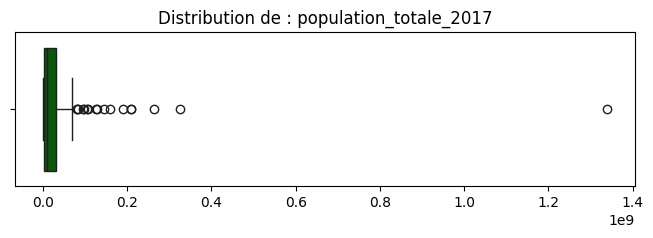

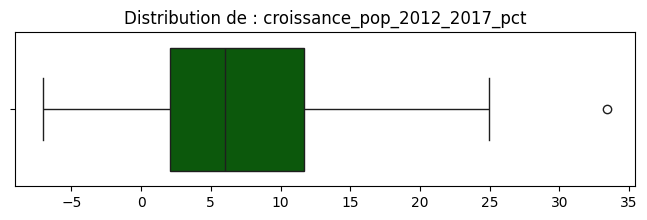

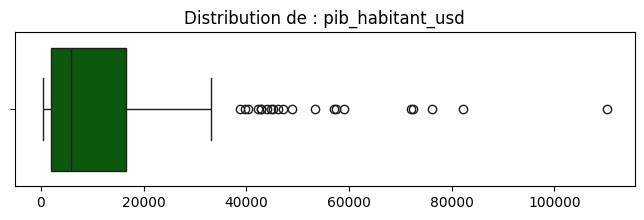

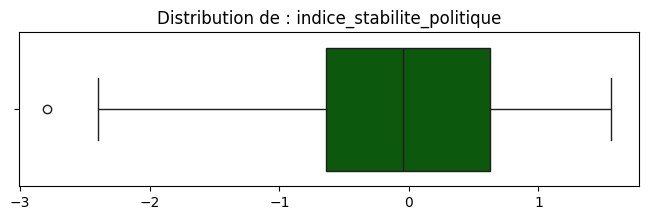

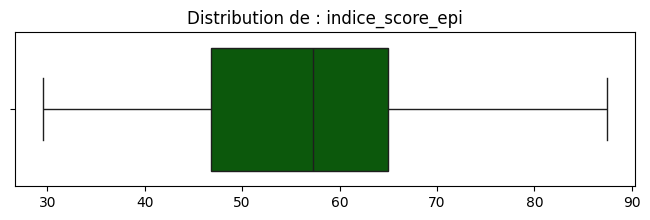

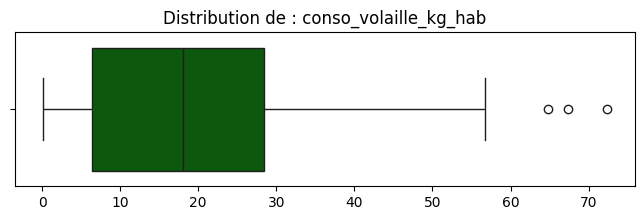

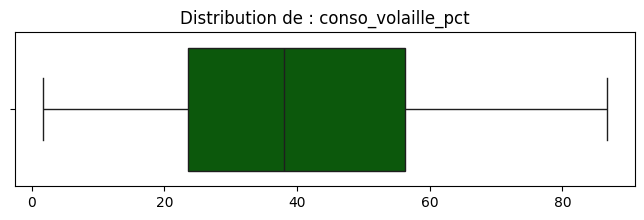

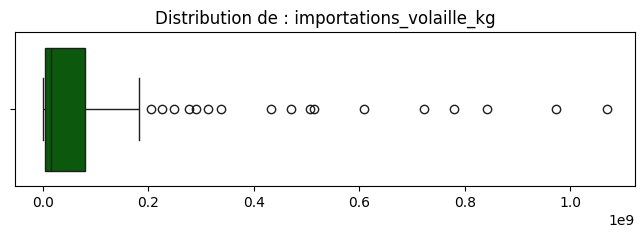

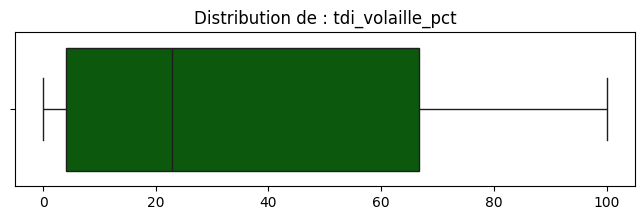

In [64]:
# Boxplot avec seaborn
for colonne in df_analyse.columns:
    if pd.api.types.is_numeric_dtype(df_analyse[colonne]):
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df_analyse[colonne], color="darkgreen")
        plt.title(f"Distribution de : {colonne}", fontsize=12)
        plt.xlabel("")
        plt.show

In [65]:
# Boxplot avec Plotly
if df_analyse.index.name == "pays":
    df_plot = df_analyse.reset_index()
else:
    df_plot = df_analyse.copy()

for colonne in df_plot.columns:
    if pd.api.types.is_numeric_dtype(df_plot[colonne]):

        fig = px.box(
            df_plot,
            x=colonne,
            hover_data=["pays"],
            points="outliers",
            title=f"Distribution de : {colonne}",
            color_discrete_sequence=["#7f9480"],
        )
        fig.show()

A la lecture de ces 9 boxplot correspondant à nos 9 variables nous avons pu identifier différents outliers comme l'Inde pour la population, Israel pour la dispo_volaille_kg_hab, le Luxembourg pour le PIB, ou le japon pour l'import de volaille.

Cela révèle que nous avons de fortes disparités mondiales. La présence de ces outliers extrêmes (mais bien réels) prouve qu'il sera indispensable de centrer et réduire (standardiser) nos données, afin que ces outliers n'écrasent pas nos autres pays.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.2 - Analyse bivariée pour explorer les corrélations</h3>
</div>

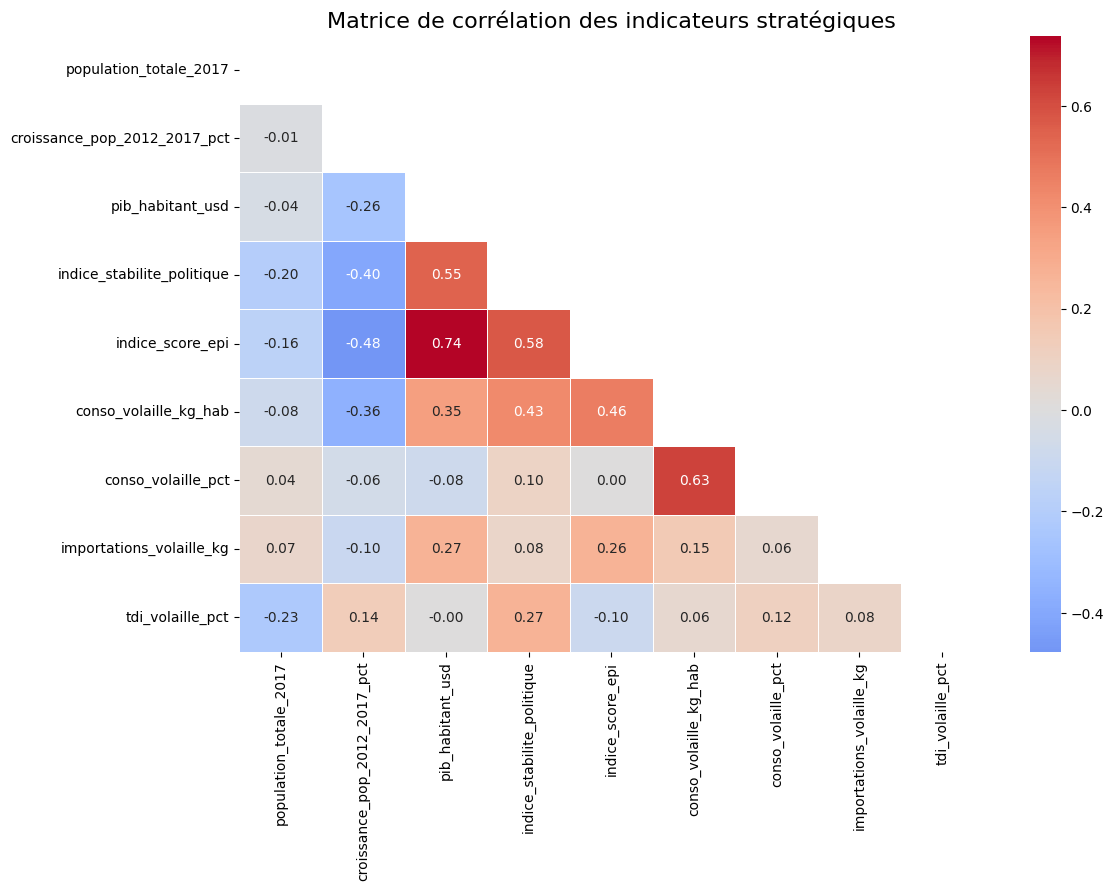

In [66]:
# Création d'une heatmap de corrélations
plt.figure(figsize=(12, 8))

# Calcul de la matrice de corrélation
matrice_corr = df_analyse.corr(numeric_only=True)
mask = np.triu(np.ones_like(matrice_corr.corr(), dtype=bool))

# Heatmap avec Seaborn
sns.heatmap(
    matrice_corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0,
)
plt.title("Matrice de corrélation des indicateurs stratégiques", fontsize=16)
plt.show()

#### Extraction automatique des corrélations 


In [67]:
# Calcul la matrice de corrélation
matrice = df_analyse.corr()

# Transformation de la heatmap en une liste de paires
paires = matrice.unstack().reset_index()
paires.columns = ["Variable 1", "Variable 2", "Correlation"]

# Nettoyage pour éviter les doublons et les paires identiques
paires_uniques = paires[paires["Variable 1"] < paires["Variable 2"]].copy()

# Création d'une colonne avec la valeur de la corrélation pour trier
paires_uniques["forte_correlation"] = paires_uniques["Correlation"].abs()

# Tri et affichage des fortes corrélations
top_correlations = paires_uniques.sort_values(by="forte_correlation", ascending=False)
display(top_correlations[["Variable 1", "Variable 2", "Correlation"]].head(15))

,Variable 1,Variable 2,Correlation
38,indice_score_epi,pib_habitant_usd,0.739042
51,conso_volaille_kg_hab,conso_volaille_pct,0.627560
39,indice_score_epi,indice_stabilite_politique,0.577237
29,indice_stabilite_politique,pib_habitant_usd,0.545267
13,croissance_pop_2012_2017_pct,indice_score_epi,-0.476543
49,conso_volaille_kg_hab,indice_score_epi,0.460069
48,conso_volaille_kg_hab,indice_stabilite_politique,0.425127
12,croissance_pop_2012_2017_pct,indice_stabilite_politique,-0.403708
46,conso_volaille_kg_hab,croissance_pop_2012_2017_pct,-0.358549
47,conso_volaille_kg_hab,pib_habitant_usd,0.347778


#### Graphiques des variables très corrélées

In [68]:
# Definition des paires que l'on souhaite analyser
paires_a_tracer = [
    ("indice_score_epi", "conso_volaille_kg_hab"),
    ("pib_habitant_usd", "conso_volaille_kg_hab"),
    ("indice_stabilite_politique", "croissance_pop_2012_2017_pct"),
]

# Afficahge des pays au survol de la souris
df_plot = df_analyse.reset_index()

# Boucle de génération des nuages de points
for variable_x, variable_y in paires_a_tracer:
    fig = px.scatter(
        df_plot,
        x=variable_x,
        y=variable_y,
        hover_name="pays",
        opacity=0.8,
        color="conso_volaille_pct",
        color_continuous_scale="Viridis",
        title=f"Relation entre {variable_x} et {variable_y}",
        trendline="ols",
    )
    fig.update_layout(height=500, width=900)
    fig.show()

Ce que nous pouvons retenir de ces 3 corrélations : 

1. **Conso volaille vs Score EPI (+0.46):** Les pays qui consomment beaucoup de volaille ont souvent un bon score EPI (écologique) car les pays qui mangent beaucoup de viande sont souvent des pays développés, qui ont aussi les moyens financiers d'investir dans des politiques environnementales.


2. **Conso Volaille vs PIB (+0.35):** La corrélation ici est positive modérée, cela nous montre que la volaille n'est pas seulement consommé par les pays ultra-riche (contrairement au bœuf).
    
3. **Croissance Population vs Stabilité Politique (-0.40) :** Nous avons ici une forte corrélation négative, les pays les plus stables politiquement (Europe, Amérique) ont une population stagnante / vieillissante. À l'inverse, les pays en pleine explosion démographique sont souvent plus instables. 

 
L'objectif de notre clustering sera justement de trouver les pays qui combinent une forte consommation de volaille, une croissance correcte, un bon score EPI ET une bonne stabilité

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.3 - Mise à disposition du fichier préparatoire au format .CSV</h3>
</div>

In [69]:
# Export du dataset df_analyse sur un fichier csv avec la date du jour
import os
import datetime

dossier_export = "csv_finaux"
os.makedirs(dossier_export, exist_ok=True)

date_du_jour = datetime.datetime.now().strftime("%d-%m-%Y")
nom_fichier = f"Fichier_Preparatoire_LaPouleQuiChante_{date_du_jour}.csv"

chemin_complet = os.path.join(dossier_export, nom_fichier)

df_analyse.to_csv(chemin_complet, index=True, float_format="%.3f", na_rep="", sep=",")
print(f"Export du fichier prêt dans {chemin_complet}")

Export du fichier prêt dans csv_finaux\Fichier_Preparatoire_LaPouleQuiChante_24-03-2026.csv
